In [1]:
#Get the necesssary things from the library
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


car_data = pd.read_csv("car.csv") #Reads the data from the csv

#Checks the data if there anything missing or has a question mark
print(car_data.isnull().sum())
print("\n")
print((car_data == "?").sum())
car_data.head()


MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
US Made         0
dtype: int64


MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
US Made         0
dtype: int64


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,US Made
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


In [2]:
#This is the section where it cleans the data from the csv

 # This would standardize the column name and get rid of unnecessary spaces
car_data.columns = car_data.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)


#Checks to see which columns are categorical and numerical
categorical_columns = car_data.select_dtypes(include="object").columns
print(categorical_columns)
numerical_columns = car_data.select_dtypes(include="number").columns
print(numerical_columns)

#Checks to see if there are any duplicated data
duplicate_count = car_data.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")
car_data = car_data.drop_duplicates().reset_index(drop=True)

#Converts the horsepower column from categorical to numeric
car_data["horsepower"] = pd.to_numeric(car_data["horsepower"],errors="coerce")

#Replaces all of the data that has ? into recognized missing data
car_data.replace("?",np.nan, inplace = True)

#Uses the median value from the horsepower to replace recognized missing datas and checks again too
median_value = car_data["horsepower"].median()
car_data["horsepower"] = car_data["horsepower"].fillna(median_value)

print(car_data.isnull().sum())
print("\n")
print((car_data == "?").sum())




Index(['horsepower'], dtype='object')
Index(['mpg', 'cylinders', 'displacement', 'weight', 'acceleration',
       'model_year', 'us_made'],
      dtype='object')
Number of exact duplicate rows: 0
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
us_made         0
dtype: int64


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
us_made         0
dtype: int64


In [3]:
#Splitting the data up into training and test datasets

x = car_data.drop(columns=["mpg"]) #The independent variables and remove the ones that aren't meaningful to the model
y = car_data["mpg"] #The dependent or target variable

#Uses the train_test_split function to split up the data into training and test datasets.
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size = 0.3, random_state =42)


In [4]:
#This cell creates the OLS  linear regression  for the training data

x2 = sm.add_constant(X_train) # add our constant y = mx+b

est = sm.OLS(Y_train,x2)  # call linear regression with OLS with Y(depdendent) & X (independant + const)

est2 = est.fit() #builds the model

print(est2.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     170.2
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           3.76e-95
Time:                        20:49:25   Log-Likelihood:                -734.38
No. Observations:                 278   AIC:                             1485.
Df Residuals:                     270   BIC:                             1514.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -19.9980      5.858     -3.414   

In [5]:
#Now this cell uses the trained model with the test data set to see if it accurately predicts the MPG

x2test = sm.add_constant(X_test) #Adds the test variables as constants

# Uses regression model trained on the testing data to predict mpg with the test data
y_pred = est2.predict(x2test) 

# calculates the R^2 to measure the accuracy of the model between the predicted and actual
test_r2 = r2_score(Y_test,y_pred)

#Calculates the root mean square error to measure prediction accuracy in original units
test_rmse = np.sqrt(mean_squared_error(Y_test,y_pred))

print("For the test data: \n")
print(f"R^2 = {test_r2:.4f}")
print(f"RMSE = {test_rmse:.4f} MPG")

For the test data: 

R^2 = 0.8399
RMSE = 3.0311 MPG


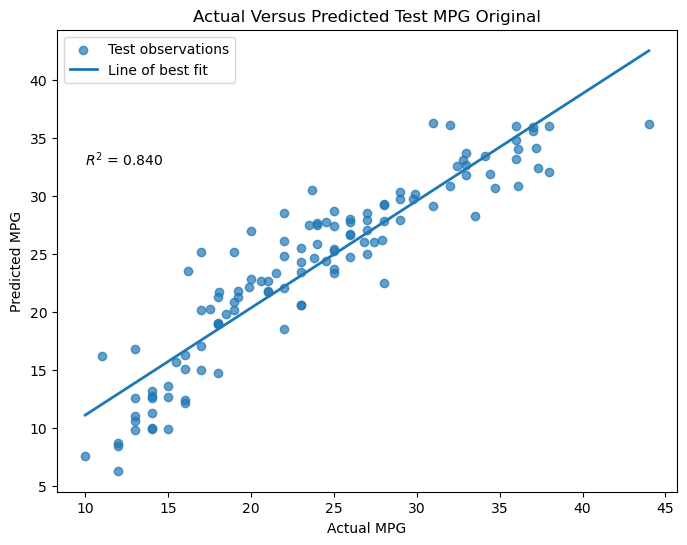

Best-fit equation: Predicted MPG = 0.923(Actual MPG) + 1.86


In [6]:
# Calculates the slope and intercept of the best-fit line to actual vs predicted values for the original model
slope, intercept = np.polyfit(
    Y_test,
    y_pred,
    1
)

# Creates ordered x-values for drawing the line from minimum to maximum actual prices
fit_x = np.linspace(
    Y_test.min(),
    Y_test.max(),
    100
)

# Calculates the corresponding y-values using linear equation
fit_y = slope * fit_x + intercept

plt.figure(figsize=(8, 6))

# Plots the actual and predicted MPG for test datasets with  actual MPG on x-axis and predicted MPG on y-axis
plt.scatter(
    Y_test,
    y_pred,
    alpha=0.7,
    label="Test observations" 
)

# Draws the line of best fit with a legend label
plt.plot(
    fit_x,
    fit_y,
    linewidth=2,
    label="Line of best fit"
)

#Adds labels and title
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual Versus Predicted Test MPG Original")

#Adds the R^2 score at top left of the model
plt.text(
    Y_test.min(),
    y_pred.max() * 0.90,
    f"$R^2$ = {test_r2:.3f}"
)

plt.legend()
plt.show()

print( #Prints the linear equation of the best-fit line
    f"Best-fit equation: "
    f"Predicted MPG = {slope:.3f}(Actual MPG) "
    f"+ {intercept:.2f}"
)

In [7]:
def backward_elimination(X_train, Y_train, alpha=0.05):
    """
    Does backward stepwise selection on the predictors until only significant(p-value < 0.05)
    predictors are left.

    This function begins with every predictor in the model. During each iteration, it removes
    The predictor with the highest p-value that is higher than 0.05 would be removed, since
    it doesn't contribute much to the model. It will stop once the remaining significant predictors are left (p-value <0.05)

    Parameters
    --------------
    X_train : pandas.DataFrame
        The training data that contains independent or predictor variables
    Y_train: pandas.Series
        Training data that contains the dependent or target variable
    alpha: float
        Significance level used to determine whether a predictor should
        remain in the model. The default value is 0.05.

    Returns
    ------------
    Selected_features: list
        Names of the predictors retained after backward stepwise selection

    model: statsmodel OLS linear regression model
        The final fitted OLS regression model contains only the selected
        predictors.

    
    """
    selected_features = list(X_train.columns)

    while True:

        X_selected = sm.add_constant(X_train[selected_features])

        model = sm.OLS(Y_train, X_selected).fit()

        p_values = model.pvalues.drop("const")

        highest_p_value = p_values.max()
        feature_to_remove = p_values.idxmax()

        if highest_p_value > alpha:
            print(f"Removing {feature_to_remove}: " f"p-value = {highest_p_value:.5f}")

            selected_features.remove(feature_to_remove)

        else:
            break

    return selected_features, model

In [8]:
#Runs an optimization of the model functions and shows the result of it
selected_features, optimized_model = backward_elimination(X_train, Y_train)

#Shows the result of the optimization, where it shows the remaining predictors and the model's summary
print("\nSelected features:")
print(selected_features)

print("\nOptimized model:")
print(optimized_model.summary())

Removing cylinders: p-value = 0.98213
Removing horsepower: p-value = 0.67358
Removing acceleration: p-value = 0.10471
Removing displacement: p-value = 0.26472

Selected features:
['weight', 'model_year', 'us_made']

Optimized model:
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     395.8
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           2.98e-99
Time:                        20:49:25   Log-Likelihood:                -736.45
No. Observations:                 278   AIC:                             1481.
Df Residuals:                     274   BIC:                             1495.
Df Model:                           3                                         
Covariance Type:            nonrobust                   

In [9]:
#Now to use the "optimized" model to predict the mpg from the test data

x3test = sm.add_constant(X_test[selected_features]) #Add the constants of the selected features

#Predict the MPG using the optimized model with the new constant with the test data
y_pred2 = optimized_model.predict(x3test)

#Calculate the optimized model's test R^2
test2_r2 = r2_score(Y_test, y_pred2)

# Calculate the optimized model's test RMSE
test2_rmse = np.sqrt(mean_squared_error(Y_test,y_pred2))

print("For the test data with optimized model:")
print(f"R^2 = {test2_r2:.4f}")
print(f"RMSE = {test2_rmse:.4f} MPG")


For the test data with optimized model:
R^2 = 0.8333
RMSE = 3.0928 MPG


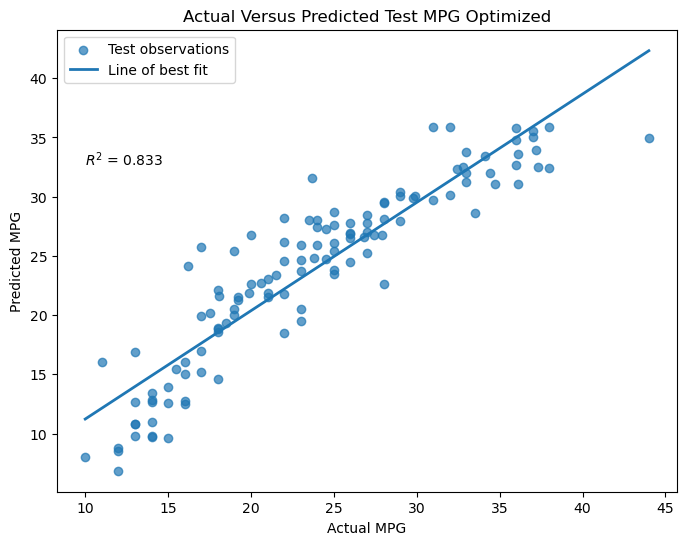

Best-fit equation: Predicted MPG = 0.915(Actual MPG) + 2.08


In [10]:
# Calculates the slope and intercept of the best-fit line to actual vs predicted values for the optimized model
#with the significant predictors only
slope, intercept = np.polyfit(
    Y_test,
    y_pred2,
    1
)

# Creates ordered x-values for drawing the line from minimum to maximum actual prices
fit_x = np.linspace(
    Y_test.min(),
    Y_test.max(),
    100
)

# Calculates the corresponding y-values using a linear equation
fit_y = slope * fit_x + intercept

plt.figure(figsize=(8, 6))

# Plots the actual and predicted MPG for test datasets with  actual MPG on x-axis and predicted MPG on y-axis
plt.scatter(
    Y_test,
    y_pred2,
    alpha=0.7,
    label="Test observations" 
)

# Draws the line of best fit with a legend label
plt.plot(
    fit_x,
    fit_y,
    linewidth=2,
    label="Line of best fit"
)

#Adds labels and title
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual Versus Predicted Test MPG Optimized")

#Adds the R^2 score at top left of the model
plt.text(
    Y_test.min(),
    y_pred.max() * 0.90,
    f"$R^2$ = {test2_r2:.3f}"
)

plt.legend()
plt.show()

print( #Prints the linear equation of the best-fit line
    f"Best-fit equation: "
    f"Predicted MPG = {slope:.3f}(Actual MPG) "
    f"+ {intercept:.2f}"
)